## Explore dataset and show some images

Number of classes: 260


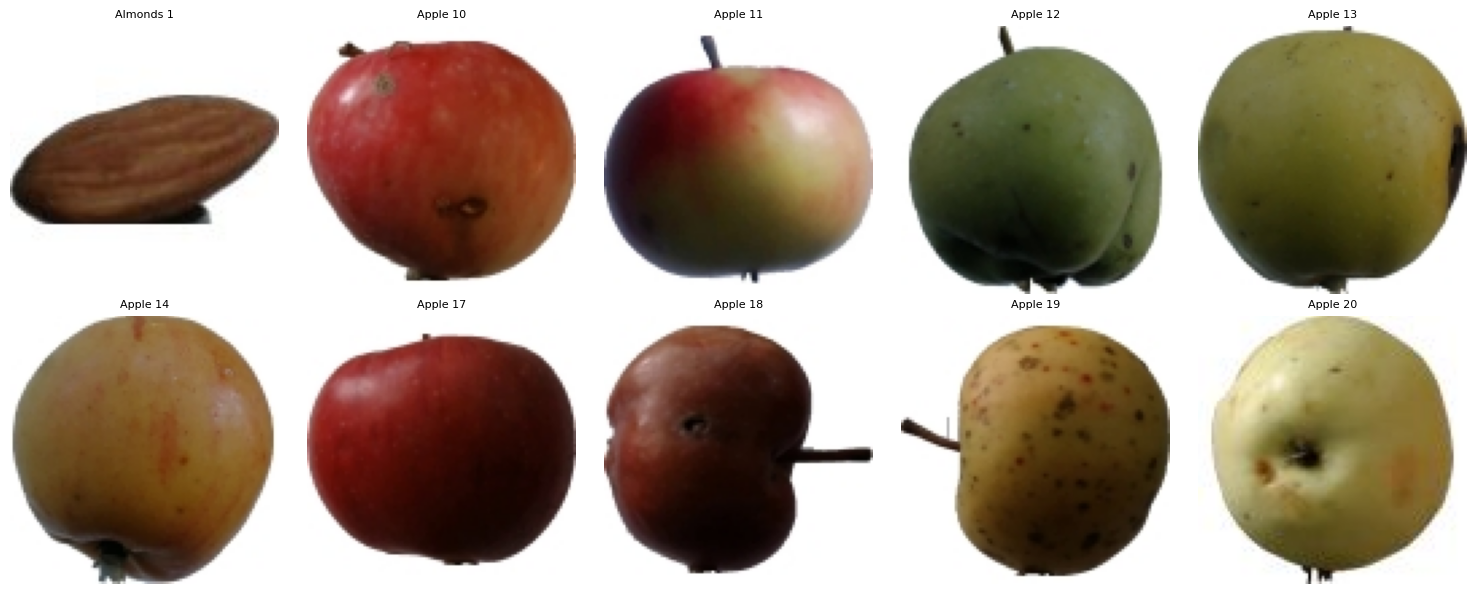

In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_dir = "fruits-360_100x100/fruits-360/Training"
test_dir = "fruits-360_100x100/fruits-360/Test"

classes = os.listdir(train_dir)
print("Number of classes:", len(classes))

fig, axes = plt.subplots(2, 5, figsize = (15, 6))
for i, cls in enumerate(classes[:10]):
    image_path = os.path.join(train_dir, cls, os.listdir(os.path.join(train_dir, cls))[0])
    image = mpimg.imread(image_path)
    axes[i//5, i%5].imshow(image)
    axes[i//5, i%5].set_title(cls, fontsize = 8)
    axes[i//5, i%5].axis('off')
plt.tight_layout()
plt.show()

## Preprocessing

### Save preprocessed dataset for submission

The assignment requires pre-processed dataset versions in the submitted zip file. The following cell creates a physical dataset folder with Training, Validation and Test splits for submission. Pixel normalization and augmentation are still applied during training with Keras generators.


In [5]:
import os
import shutil
import json
from pathlib import Path
from sklearn.model_selection import train_test_split

# Physical preprocessed dataset folder for the project submission zip.
# The original Fruits-360 images are already 100x100 RGB.
# Normalization (rescale=1./255) and augmentation are applied during training.
PREPROCESSED_DIR = Path("preprocessed_datasets/fruits_360_cnn")
preprocessed_train_dir = PREPROCESSED_DIR / "Training"
preprocessed_val_dir = PREPROCESSED_DIR / "Validation"
preprocessed_test_dir = PREPROCESSED_DIR / "Test"

OVERWRITE_PREPROCESSED_DATASET = False
SEED = 42
VALIDATION_SIZE = 0.2
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

if PREPROCESSED_DIR.exists() and not OVERWRITE_PREPROCESSED_DATASET:
    print(f"Preprocessed dataset already exists: {PREPROCESSED_DIR}")
    print("Set OVERWRITE_PREPROCESSED_DATASET = True if you want to recreate it.")
else:
    if PREPROCESSED_DIR.exists():
        shutil.rmtree(PREPROCESSED_DIR)

    for folder in [preprocessed_train_dir, preprocessed_val_dir, preprocessed_test_dir]:
        folder.mkdir(parents=True, exist_ok=True)

    classes = sorted([
        cls for cls in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, cls))
    ])

    for cls in classes:
        source_class_dir = Path(train_dir) / cls
        images = sorted([
            img for img in os.listdir(source_class_dir)
            if Path(img).suffix.lower() in IMAGE_EXTENSIONS
        ])

        train_images, val_images = train_test_split(
            images,
            test_size=VALIDATION_SIZE,
            random_state=SEED,
            shuffle=True
        )

        train_class_dir = preprocessed_train_dir / cls
        val_class_dir = preprocessed_val_dir / cls
        train_class_dir.mkdir(parents=True, exist_ok=True)
        val_class_dir.mkdir(parents=True, exist_ok=True)

        for img in train_images:
            shutil.copy2(source_class_dir / img, train_class_dir / img)

        for img in val_images:
            shutil.copy2(source_class_dir / img, val_class_dir / img)

    for cls in classes:
        source_class_dir = Path(test_dir) / cls
        if not source_class_dir.exists():
            continue

        test_class_dir = preprocessed_test_dir / cls
        test_class_dir.mkdir(parents=True, exist_ok=True)

        for img in sorted(os.listdir(source_class_dir)):
            if Path(img).suffix.lower() in IMAGE_EXTENSIONS:
                shutil.copy2(source_class_dir / img, test_class_dir / img)

    class_indices = {cls: index for index, cls in enumerate(classes)}
    with open(PREPROCESSED_DIR / "class_indices.json", "w", encoding="utf-8") as f:
        json.dump(class_indices, f, indent=2)

    readme_lines = [
        "Preprocessed Fruits-360 dataset for the CNN task.",
        "",
        "Contents:",
        "- Training: 80% split from the original Fruits-360 Training folder.",
        "- Validation: 20% split from the original Fruits-360 Training folder.",
        "- Test: copy of the original Fruits-360 Test folder.",
        "- class_indices.json: class label to index mapping.",
        "",
        "Preprocessing notes:",
        "- Original images are already standardized to 100x100 RGB.",
        "- Pixel normalization with rescale=1./255 is applied during model training.",
        "- Data augmentation is applied on the fly during training and is not saved as image files.",
        "- The split uses random_state=42 for reproducibility.",
    ]
    with open(PREPROCESSED_DIR / "README.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(readme_lines) + "\n")

    print(f"Saved preprocessed dataset to: {PREPROCESSED_DIR}")
    print(f"Classes: {len(classes)}")
    print(f"Training folders: {len(list(preprocessed_train_dir.iterdir()))}")
    print(f"Validation folders: {len(list(preprocessed_val_dir.iterdir()))}")
    print(f"Test folders: {len(list(preprocessed_test_dir.iterdir()))}")



Saved preprocessed dataset to: preprocessed_datasets/fruits_360_cnn
Classes: 260
Training folders: 260
Validation folders: 260
Test folders: 260


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (100, 100)
BATCH_SIZE = 32
SEED = 42

# [0,255] → [0,1] and validation split
datagen_val_train = ImageDataGenerator(
    rescale=1./255, 
    validation_split = 0.2
)
datagen_test  = ImageDataGenerator(
    rescale=1./255
)

train_generator = datagen_val_train.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,   # images 100x100
    batch_size = BATCH_SIZE,    # 32 images per training step
    class_mode='categorical',
    subset  = "training",
    seed = SEED,
    shuffle = True
)

val_generator = datagen_val_train.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode='categorical',
    subset  = "validation",
    seed = SEED,
    shuffle = False
)

test_generator = datagen_test.flow_from_directory(
    test_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Test images:", test_generator.samples)
print("Number of classes:", len(train_generator.class_indices))

2026-06-14 04:39:16.467791: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-14 04:39:16.763925: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-14 04:39:16.824393: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-14 04:39:16.824424: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not ha

Found 109865 images belonging to 260 classes.
Found 27356 images belonging to 260 classes.
Found 45724 images belonging to 260 classes.
Training images: 109865
Validation images: 27356
Test images: 45724
Number of classes: 260


## Generator with Data Augmentation

A mild data augmentation setting is used because the Fruits-360 images are already centered, segmented and captured on a clean background.

In [ ]:
augmented_train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1
)

augmented_train_generator = augmented_train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED,
    shuffle=True
)

Found 109865 images belonging to 260 classes.


## Experiment 1: CNN Modell

First experiment using the CNN architectur.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization)

num_classes = len(train_generator.class_indices)

model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation = 'relu', padding = 'same', input_shape = (100, 100, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classification
    Flatten(),
    Dense(256, activation = 'relu'),
    Dropout(0.5),
    Dense(num_classes, activation = 'softmax')
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 100, 100, 32)      896       
                                                                 
 batch_normalization_3 (Batc  (None, 100, 100, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 50, 50, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 50, 50, 64)        18496     
                                                                 
 batch_normalization_4 (Batc  (None, 50, 50, 64)       256       
 hNormalization)                                                 
                                                      

Compile

In [11]:
model.compile(
    optimizer='adam',        # Warum Adam? Adaptiver Lernrate, sehr robust
    loss='categorical_crossentropy',  # Warum? Standard für Mehrklassen-Klassifikation
    metrics=['accuracy']     # Warum? Direkt interpretierbar
)

Train

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model_baseline.h5",
    save_best_only=True
)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
3434/3434 [==============================] - 1557s 453ms/step - loss: 5.4007 - accuracy: 0.0111 - val_loss: 5.1066 - val_accuracy: 0.0321
Epoch 2/30
3434/3434 [==============================] - 1172s 341ms/step - loss: 5.1626 - accuracy: 0.0235 - val_loss: 4.6953 - val_accuracy: 0.0639
Epoch 3/30
3434/3434 [==============================] - 912s 266ms/step - loss: 4.6404 - accuracy: 0.0721 - val_loss: 3.5910 - val_accuracy: 0.2528
Epoch 4/30
3434/3434 [==============================] - 1539s 448ms/step - loss: 2.3494 - accuracy: 0.4396 - val_loss: 0.4752 - val_accuracy: 0.8605
Epoch 5/30
3434/3434 [==============================] - 1309s 381ms/step - loss: 0.4119 - accuracy: 0.8701 - val_loss: 0.3502 - val_accuracy: 0.9031
Epoch 6/30
3434/3434 [==============================] - 796s 232ms/step - loss: 0.1836 - accuracy: 0.9401 - val_loss: 0.2800 - val_accuracy: 0.9232
Epoch 7/30
3434/3434 [==============================] - 803s 234ms/step - loss: 0.1199 - accuracy: 0.9614 - 

Plot

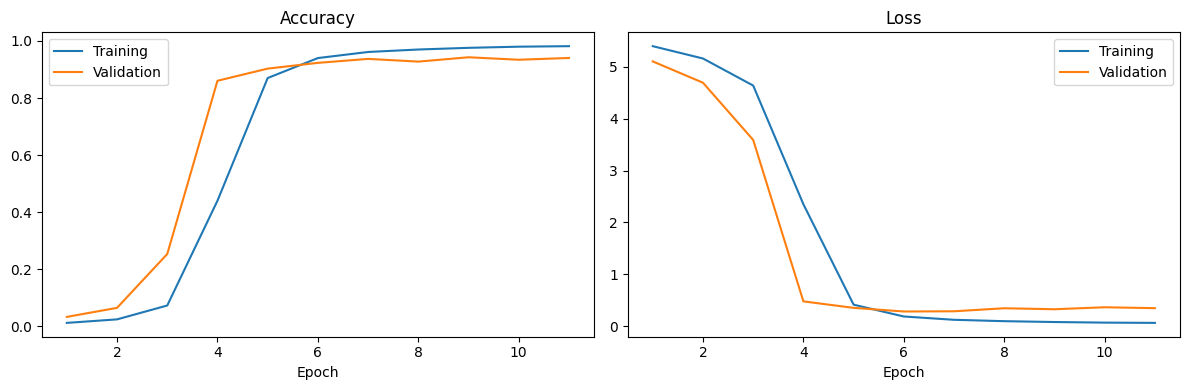

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history.history["accuracy"]) + 1)

# accuracy
ax1.plot(epochs_range, history.history["accuracy"], label="Training")
ax1.plot(epochs_range, history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()

# loss
ax2.plot(epochs_range, history.history["loss"], label="Training")
ax2.plot(epochs_range, history.history["val_loss"], label="Validation")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig("erster_test.png")
plt.show()

Analysis

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
print(confusion_matrix(y_true, y_pred))

1429/1429 [==============================] - 221s 154ms/step
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       1.00      0.96      0.98       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       1.00      0.97      0.99       154
              Apple 13       0.98      1.00      0.99       235
              Apple 14       0.87      1.00      0.93       154
              Apple 17       0.99      0.92      0.96       201
              Apple 18       1.00      0.96      0.98       240
              Apple 19       1.00      1.00      1.00       241
              Apple 20       1.00      1.00      1.00       234
              Apple 21       1.00      0.99      1.00       162
              Apple 22       1.00      0.98      0.99       231
              Apple 23       0.85      1.00      0.92       156
               Apple 5       0.99      1.0

## Experiment 2: CNN with Data Augmentation

Second experiment using the same CNN architecture, but training with data augmentation.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

num_classes = len(train_generator.class_indices)

model_aug = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(100, 100, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classification
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model_aug.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 100, 100, 32)      896       
                                                                 
 batch_normalization_3 (Batc  (None, 100, 100, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 50, 50, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 50, 50, 64)        18496     
                                                                 
 batch_normalization_4 (Batc  (None, 50, 50, 64)       256       
 hNormalization)                                                 
                                                      

In [9]:
model_aug.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_aug = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_aug = ModelCheckpoint(
    "best_model_augmented.h5",
    save_best_only=True
)

history_aug = model_aug.fit(
    augmented_train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop_aug, checkpoint_aug]
)

Epoch 1/30
3434/3434 [==============================] - 1044s 304ms/step - loss: 5.5340 - accuracy: 0.0073 - val_loss: 5.5102 - val_accuracy: 0.0072
Epoch 2/30
3434/3434 [==============================] - 988s 288ms/step - loss: 5.5086 - accuracy: 0.0069 - val_loss: 5.5057 - val_accuracy: 0.0072
Epoch 3/30
3434/3434 [==============================] - 985s 287ms/step - loss: 5.5068 - accuracy: 0.0071 - val_loss: 5.5051 - val_accuracy: 0.0072
Epoch 4/30
3434/3434 [==============================] - 901s 262ms/step - loss: 5.5065 - accuracy: 0.0068 - val_loss: 5.5050 - val_accuracy: 0.0071
Epoch 5/30
2848/3434 [=======================>......] - ETA: 2:13 - loss: 5.5069 - accuracy: 0.0072

KeyboardInterrupt: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range_aug = range(1, len(history_aug.history["accuracy"]) + 1)

# accuracy
ax1.plot(epochs_range_aug, history_aug.history["accuracy"], label="Training")
ax1.plot(epochs_range_aug, history_aug.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy with Data Augmentation")
ax1.set_xlabel("Epoch")
ax1.legend()

# loss
ax2.plot(epochs_range_aug, history_aug.history["loss"], label="Training")
ax2.plot(epochs_range_aug, history_aug.history["val_loss"], label="Validation")
ax2.set_title("Loss with Data Augmentation")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig("erster_test_augmented.png")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_generator.reset()
y_pred_probs_aug = model_aug.predict(test_generator)
y_pred_aug = np.argmax(y_pred_probs_aug, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred_aug, target_names=class_names, zero_division=0))
print(confusion_matrix(y_true, y_pred_aug))

## Recorded Result for Experiment 2: CNN with Data Augmentation

The data augmentation experiment was completed in a previous successful run. The resulting plot and metrics are included below and are used for the final comparison table. A later rerun became stuck near random accuracy during the first epochs and was therefore not used as the final result.

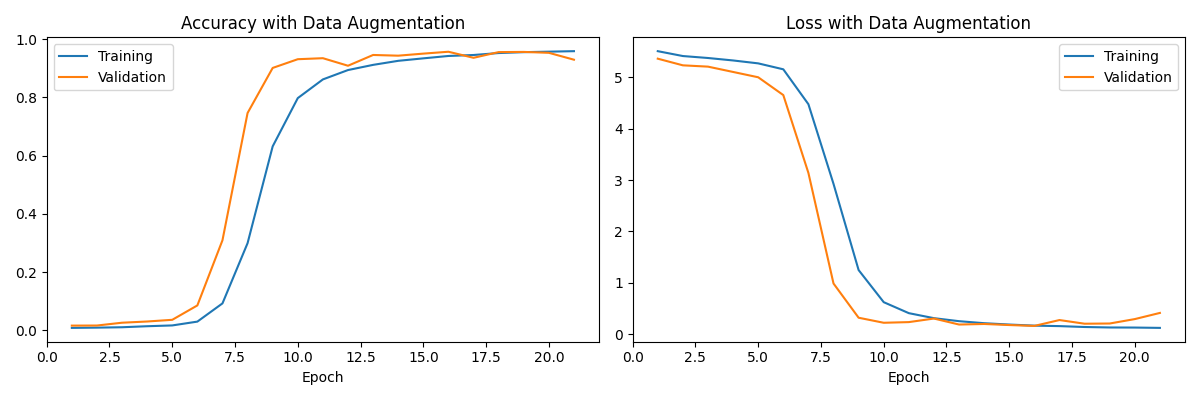

In [11]:
from IPython.display import Image, display

display(Image(filename="erster_test_augmented.png"))

In [ ]:
import pandas as pd

experiment_2_recorded_result = {
    "Experiment": "CNN + Data Augmentation",
    "Test Accuracy": 0.95,
    "Macro Precision": 0.96,
    "Macro Recall": 0.95,
    "Macro F1-score": 0.95,
    "Notes": "Completed run with mild augmentation; values match the final comparison table."
}

pd.DataFrame([experiment_2_recorded_result])

## Experiment 3: Small CNN without Data Augmentation

This experiment uses fewer convolutional filters than the baseline model.
Goal: evaluate whether a smaller model can achieve similar performance with fewer parameters

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

num_classes = len(train_generator.class_indices)

model_small = Sequential([
    # Block 1: fewer filters than baseline
    Conv2D(16, (3, 3), activation="relu", padding="same", input_shape=(100, 100, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classification
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model_small.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 100, 100, 16)      448       
                                                                 
 batch_normalization_9 (Batc  (None, 100, 100, 16)     64        
 hNormalization)                                                 
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 50, 50, 16)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 50, 50, 32)        4640      
                                                                 
 batch_normalization_10 (Bat  (None, 50, 50, 32)       128       
 chNormalization)                                                
                                                      

In [22]:
model_small.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_small = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_small = ModelCheckpoint(
    "best_model_small.h5",
    save_best_only=True
)

history_small = model_small.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop_small, checkpoint_small]
)

Epoch 1/30
3434/3434 [==============================] - 673s 196ms/step - loss: 3.6643 - accuracy: 0.1883 - val_loss: 1.0505 - val_accuracy: 0.7244
Epoch 2/30
3434/3434 [==============================] - 669s 195ms/step - loss: 1.2627 - accuracy: 0.6359 - val_loss: 0.3297 - val_accuracy: 0.8987
Epoch 3/30
3434/3434 [==============================] - 663s 193ms/step - loss: 0.3779 - accuracy: 0.8783 - val_loss: 0.2404 - val_accuracy: 0.9279
Epoch 4/30
3434/3434 [==============================] - 665s 194ms/step - loss: 0.1645 - accuracy: 0.9460 - val_loss: 0.2896 - val_accuracy: 0.9341
Epoch 5/30
3434/3434 [==============================] - 664s 193ms/step - loss: 0.1065 - accuracy: 0.9658 - val_loss: 0.1739 - val_accuracy: 0.9524
Epoch 6/30
3434/3434 [==============================] - 665s 194ms/step - loss: 0.0735 - accuracy: 0.9769 - val_loss: 0.1284 - val_accuracy: 0.9652
Epoch 7/30
3434/3434 [==============================] - 664s 193ms/step - loss: 0.0588 - accuracy: 0.9817 - val_

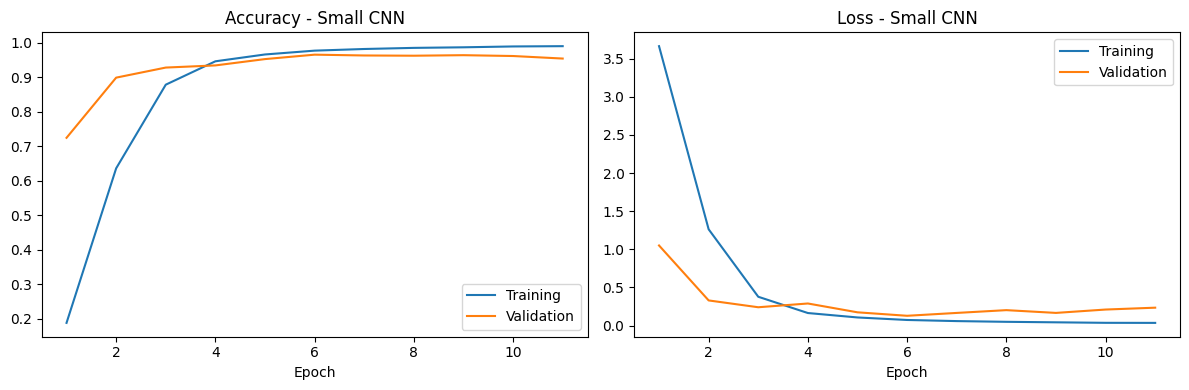

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range_small = range(1, len(history_small.history["accuracy"]) + 1)

# accuracy
ax1.plot(epochs_range_small, history_small.history["accuracy"], label="Training")
ax1.plot(epochs_range_small, history_small.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy - Small CNN")
ax1.set_xlabel("Epoch")
ax1.legend()

# loss
ax2.plot(epochs_range_small, history_small.history["loss"], label="Training")
ax2.plot(epochs_range_small, history_small.history["val_loss"], label="Validation")
ax2.set_title("Loss - Small CNN")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig("small_cnn.png")
plt.show()

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_generator.reset()
y_pred_probs_small = model_small.predict(test_generator)
y_pred_small = np.argmax(y_pred_probs_small, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred_small, target_names=class_names, zero_division=0))
print(confusion_matrix(y_true, y_pred_small))

1429/1429 [==============================] - 198s 138ms/step
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       0.99      0.98      0.98       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       0.98      0.92      0.95       154
              Apple 13       1.00      1.00      1.00       235
              Apple 14       1.00      0.99      1.00       154
              Apple 17       0.98      1.00      0.99       201
              Apple 18       1.00      0.95      0.98       240
              Apple 19       1.00      1.00      1.00       241
              Apple 20       1.00      1.00      1.00       234
              Apple 21       1.00      1.00      1.00       162
              Apple 22       1.00      1.00      1.00       231
              Apple 23       1.00      1.00      1.00       156
               Apple 5       1.00      1.0

## Experiment 4: Large CNN without Data Augmentation

This experiment uses more convolutional filters than the baseline model.
Goal: evaluate whether increasing model capacity improves performance or leads to unnecessary complexity or overfitting

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

num_classes = len(train_generator.class_indices)

model_large = Sequential([
    # Block 1: more filters than baseline
    Conv2D(64, (3, 3), activation="relu", padding="same", input_shape=(100, 100, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(256, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classification
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model_large.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 100, 100, 64)      1792      
                                                                 
 batch_normalization_12 (Bat  (None, 100, 100, 64)     256       
 chNormalization)                                                
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 50, 50, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 50, 50, 128)       73856     
                                                                 
 batch_normalization_13 (Bat  (None, 50, 50, 128)      512       
 chNormalization)                                                
                                                      

In [27]:
from tensorflow.keras.optimizers import Adam

model_large.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_large = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_large = ModelCheckpoint(
    "best_model_large_lr0001.h5",
    save_best_only=True
)

history_large = model_large.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop_large, checkpoint_large]
)

Epoch 1/30
3434/3434 [==============================] - 1280s 373ms/step - loss: 1.7437 - accuracy: 0.6111 - val_loss: 0.2532 - val_accuracy: 0.9249
Epoch 2/30
3434/3434 [==============================] - 1284s 374ms/step - loss: 0.1821 - accuracy: 0.9443 - val_loss: 0.1622 - val_accuracy: 0.9576
Epoch 3/30
3434/3434 [==============================] - 1258s 366ms/step - loss: 0.0886 - accuracy: 0.9724 - val_loss: 0.1832 - val_accuracy: 0.9552
Epoch 4/30
3434/3434 [==============================] - 1243s 362ms/step - loss: 0.0605 - accuracy: 0.9818 - val_loss: 0.1995 - val_accuracy: 0.9474
Epoch 5/30
3434/3434 [==============================] - 1233s 359ms/step - loss: 0.0476 - accuracy: 0.9855 - val_loss: 0.1503 - val_accuracy: 0.9622
Epoch 6/30
3434/3434 [==============================] - 1231s 358ms/step - loss: 0.0390 - accuracy: 0.9883 - val_loss: 0.1688 - val_accuracy: 0.9635
Epoch 7/30
3434/3434 [==============================] - 1226s 357ms/step - loss: 0.0313 - accuracy: 0.9911

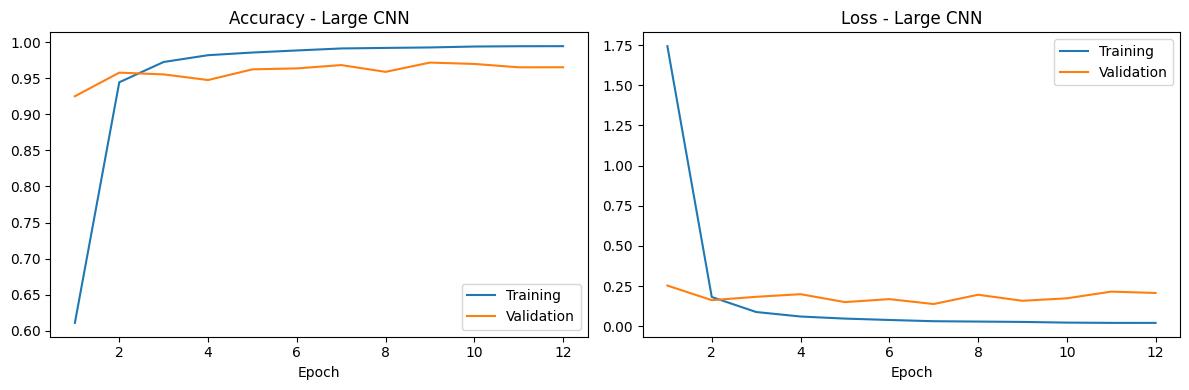

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range_large = range(1, len(history_large.history["accuracy"]) + 1)

# accuracy
ax1.plot(epochs_range_large, history_large.history["accuracy"], label="Training")
ax1.plot(epochs_range_large, history_large.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy - Large CNN")
ax1.set_xlabel("Epoch")
ax1.legend()

# loss
ax2.plot(epochs_range_large, history_large.history["loss"], label="Training")
ax2.plot(epochs_range_large, history_large.history["val_loss"], label="Validation")
ax2.set_title("Loss - Large CNN")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig("large_cnn.png")
plt.show()

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_generator.reset()
y_pred_probs_large = model_large.predict(test_generator)
y_pred_large = np.argmax(y_pred_probs_large, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred_large, target_names=class_names, zero_division=0))
print(confusion_matrix(y_true, y_pred_large))

1429/1429 [==============================] - 254s 178ms/step
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       1.00      0.99      1.00       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       1.00      1.00      1.00       154
              Apple 13       1.00      1.00      1.00       235
              Apple 14       1.00      0.98      0.99       154
              Apple 17       1.00      0.86      0.92       201
              Apple 18       0.96      1.00      0.98       240
              Apple 19       1.00      1.00      1.00       241
              Apple 20       1.00      1.00      1.00       234
              Apple 21       1.00      0.98      0.99       162
              Apple 22       1.00      1.00      1.00       231
              Apple 23       1.00      1.00      1.00       156
               Apple 5       0.97      1.0

## Experiment 5: Average Pooling CNN without Data Augmentation

This experiment keeps the baseline filter configuration (32-64-128) but replaces MaxPooling2D with AveragePooling2D.
Goal: compare the impact of different pooling methods on classification performance

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Dense, Flatten, Dropout, BatchNormalization

num_classes = len(train_generator.class_indices)

model_avgpool = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(100, 100, 3)),
    BatchNormalization(),
    AveragePooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    AveragePooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    AveragePooling2D(2, 2),

    # Classification
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model_avgpool.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 100, 100, 32)      896       
                                                                 
 batch_normalization_15 (Bat  (None, 100, 100, 32)     128       
 chNormalization)                                                
                                                                 
 average_pooling2d (AverageP  (None, 50, 50, 32)       0         
 ooling2D)                                                       
                                                                 
 conv2d_16 (Conv2D)          (None, 50, 50, 64)        18496     
                                                                 
 batch_normalization_16 (Bat  (None, 50, 50, 64)       256       
 chNormalization)                                                
                                                      

In [32]:
model_avgpool.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_avgpool = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_avgpool = ModelCheckpoint(
    "best_model_avgpool.h5",
    save_best_only=True
)

history_avgpool = model_avgpool.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop_avgpool, checkpoint_avgpool]
)

Epoch 1/30
3434/3434 [==============================] - 774s 225ms/step - loss: 5.4596 - accuracy: 0.0118 - val_loss: 5.3526 - val_accuracy: 0.0133
Epoch 2/30
3434/3434 [==============================] - 776s 226ms/step - loss: 5.3609 - accuracy: 0.0142 - val_loss: 5.1278 - val_accuracy: 0.0234
Epoch 3/30
3434/3434 [==============================] - 783s 228ms/step - loss: 4.5505 - accuracy: 0.0913 - val_loss: 1.5620 - val_accuracy: 0.6108
Epoch 4/30
3434/3434 [==============================] - 784s 228ms/step - loss: 1.1848 - accuracy: 0.6589 - val_loss: 0.4102 - val_accuracy: 0.8863
Epoch 5/30
3434/3434 [==============================] - 786s 229ms/step - loss: 0.3233 - accuracy: 0.8964 - val_loss: 0.3188 - val_accuracy: 0.9193
Epoch 6/30
3434/3434 [==============================] - 787s 229ms/step - loss: 0.1682 - accuracy: 0.9447 - val_loss: 0.2767 - val_accuracy: 0.9284
Epoch 7/30
3434/3434 [==============================] - 803s 234ms/step - loss: 0.1162 - accuracy: 0.9631 - val_

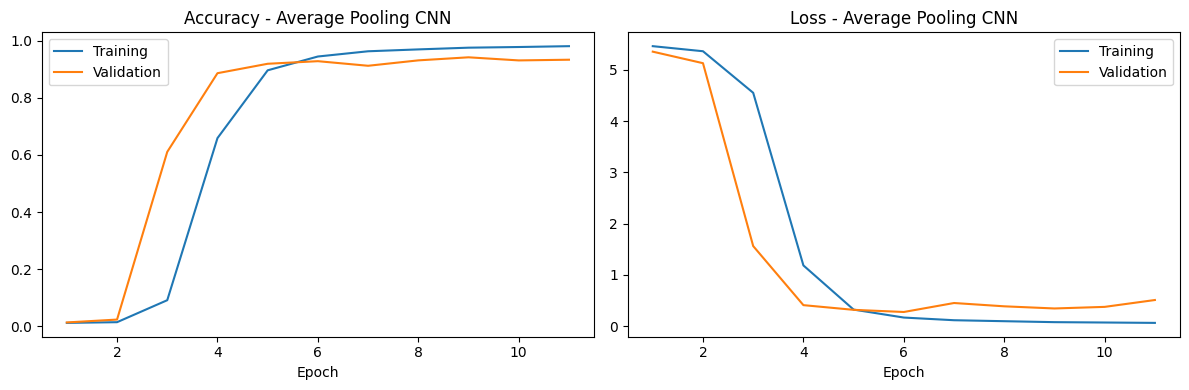

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range_avgpool = range(1, len(history_avgpool.history["accuracy"]) + 1)

# accuracy
ax1.plot(epochs_range_avgpool, history_avgpool.history["accuracy"], label="Training")
ax1.plot(epochs_range_avgpool, history_avgpool.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy - Average Pooling CNN")
ax1.set_xlabel("Epoch")
ax1.legend()

# loss
ax2.plot(epochs_range_avgpool, history_avgpool.history["loss"], label="Training")
ax2.plot(epochs_range_avgpool, history_avgpool.history["val_loss"], label="Validation")
ax2.set_title("Loss - Average Pooling CNN")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig("average_pooling_cnn.png")
plt.show()

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_generator.reset()
y_pred_probs_avgpool = model_avgpool.predict(test_generator)
y_pred_avgpool = np.argmax(y_pred_probs_avgpool, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred_avgpool, target_names=class_names, zero_division=0))
print(confusion_matrix(y_true, y_pred_avgpool))

1429/1429 [==============================] - 198s 139ms/step
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       0.98      1.00      0.99       231
              Apple 11       1.00      0.99      0.99       142
              Apple 12       0.98      0.86      0.92       154
              Apple 13       1.00      0.96      0.98       235
              Apple 14       1.00      0.90      0.95       154
              Apple 17       1.00      0.83      0.90       201
              Apple 18       0.99      0.94      0.96       240
              Apple 19       0.97      1.00      0.98       241
              Apple 20       1.00      1.00      1.00       234
              Apple 21       1.00      0.98      0.99       162
              Apple 22       0.98      0.97      0.98       231
              Apple 23       0.93      1.00      0.96       156
               Apple 5       0.96      1.0

## Experiment 6: Stride and Padding CNN without Data Augmentation

This experiment keeps the baseline filter configuration (32-64-128), but changes the first convolutional layer to use strides=(2, 2) and padding="valid". 
Goal: evaluate how stronger early downsampling and reduced border preservation affect performance

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

num_classes = len(train_generator.class_indices)

model_stride_padding = Sequential([
    # Block 1: stronger early downsampling and no zero-padding
    Conv2D(32, (3, 3), strides=(2, 2), activation="relu", padding="valid", input_shape=(100, 100, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2: baseline-style convolution
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3: baseline-style convolution
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classification
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model_stride_padding.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 49, 49, 32)        896       
                                                                 
 batch_normalization_6 (Batc  (None, 49, 49, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 24, 24, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 batch_normalization_7 (Batc  (None, 24, 24, 64)       256       
 hNormalization)                                                 
                                                      

In [17]:
model_stride_padding.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_stride_padding = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_stride_padding = ModelCheckpoint(
    "best_model_stride_padding.h5",
    save_best_only=True
)

history_stride_padding = model_stride_padding.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop_stride_padding, checkpoint_stride_padding]
)

Epoch 1/30
3434/3434 [==============================] - 628s 183ms/step - loss: 2.1264 - accuracy: 0.4691 - val_loss: 0.5638 - val_accuracy: 0.8506
Epoch 2/30
3434/3434 [==============================] - 640s 186ms/step - loss: 0.6203 - accuracy: 0.8056 - val_loss: 0.2831 - val_accuracy: 0.9091
Epoch 3/30
3434/3434 [==============================] - 644s 188ms/step - loss: 0.3000 - accuracy: 0.9028 - val_loss: 0.1639 - val_accuracy: 0.9444
Epoch 4/30
3434/3434 [==============================] - 627s 183ms/step - loss: 0.1730 - accuracy: 0.9431 - val_loss: 0.2781 - val_accuracy: 0.9370
Epoch 5/30
3434/3434 [==============================] - 624s 182ms/step - loss: 0.1182 - accuracy: 0.9612 - val_loss: 0.2460 - val_accuracy: 0.9429
Epoch 6/30
3434/3434 [==============================] - 671s 195ms/step - loss: 0.0870 - accuracy: 0.9714 - val_loss: 0.1231 - val_accuracy: 0.9605
Epoch 7/30
3434/3434 [==============================] - 640s 186ms/step - loss: 0.0664 - accuracy: 0.9780 - val_

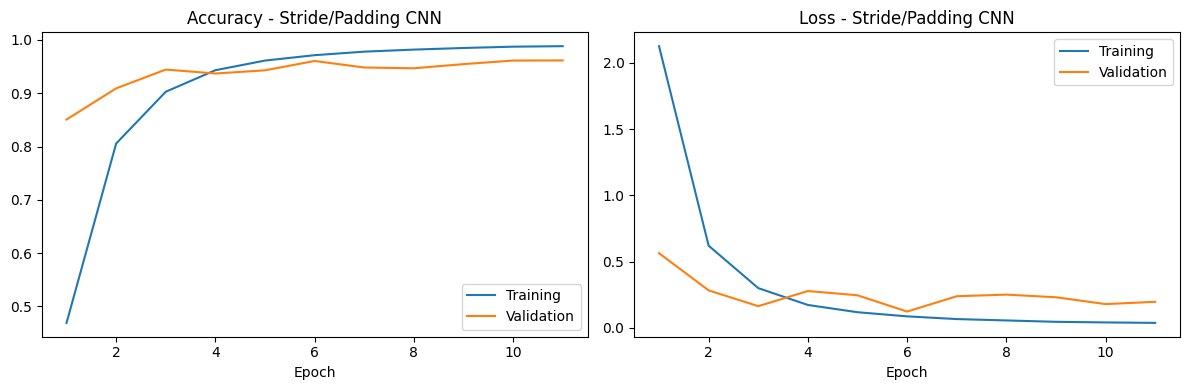

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range_stride_padding = range(1, len(history_stride_padding.history["accuracy"]) + 1)

# accuracy
ax1.plot(epochs_range_stride_padding, history_stride_padding.history["accuracy"], label="Training")
ax1.plot(epochs_range_stride_padding, history_stride_padding.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy - Stride/Padding CNN")
ax1.set_xlabel("Epoch")
ax1.legend()

# loss
ax2.plot(epochs_range_stride_padding, history_stride_padding.history["loss"], label="Training")
ax2.plot(epochs_range_stride_padding, history_stride_padding.history["val_loss"], label="Validation")
ax2.set_title("Loss - Stride/Padding CNN")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig("stride_padding_cnn.png")
plt.show()

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_generator.reset()
y_pred_probs_stride_padding = model_stride_padding.predict(test_generator)
y_pred_stride_padding = np.argmax(y_pred_probs_stride_padding, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred_stride_padding, target_names=class_names, zero_division=0))
print(confusion_matrix(y_true, y_pred_stride_padding))

1429/1429 [==============================] - 207s 145ms/step
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       1.00      0.99      0.99       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       1.00      1.00      1.00       154
              Apple 13       1.00      1.00      1.00       235
              Apple 14       1.00      1.00      1.00       154
              Apple 17       0.96      0.93      0.94       201
              Apple 18       1.00      0.97      0.99       240
              Apple 19       1.00      1.00      1.00       241
              Apple 20       1.00      1.00      1.00       234
              Apple 21       1.00      1.00      1.00       162
              Apple 22       0.98      1.00      0.99       231
              Apple 23       1.00      1.00      1.00       156
               Apple 5       1.00      1.0

## Experiment 7: Pretrained MobileNetV2

This uses transfer learning with MobileNetV2 pretrained on ImageNet. The convolutional base is frozen first, and only a small custom classifier is trained on the Fruits-360 dataset.

In [21]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

train_dir = "fruits-360_100x100/fruits-360/Training"
test_dir = "fruits-360_100x100/fruits-360/Test"

IMG_SIZE_PRETRAINED = (128, 128)
BATCH_SIZE_PRETRAINED = 32
SEED = 42
EPOCHS_PRETRAINED = 20

pretrained_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen_pretrained = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator_pretrained = pretrained_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE_PRETRAINED,
    batch_size=BATCH_SIZE_PRETRAINED,
    class_mode="categorical",
    subset="training",
    seed=SEED,
    shuffle=True
)

val_generator_pretrained = pretrained_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE_PRETRAINED,
    batch_size=BATCH_SIZE_PRETRAINED,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False
)

test_generator_pretrained = test_datagen_pretrained.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE_PRETRAINED,
    batch_size=BATCH_SIZE_PRETRAINED,
    class_mode="categorical",
    classes=list(train_generator_pretrained.class_indices.keys()),
    shuffle=False
)

num_classes_pretrained = len(train_generator_pretrained.class_indices)
print("Number of classes:", num_classes_pretrained)
print("Training images:", train_generator_pretrained.samples)
print("Validation images:", val_generator_pretrained.samples)
print("Test images:", test_generator_pretrained.samples)

Found 109865 images belonging to 260 classes.
Found 27356 images belonging to 260 classes.
Found 45724 images belonging to 260 classes.
Number of classes: 260
Training images: 109865
Validation images: 27356
Test images: 45724


In [22]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE_PRETRAINED, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes_pretrained, activation="softmax")(x)

model_mobilenet = Model(inputs=base_model.input, outputs=outputs)
model_mobilenet.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 64, 64, 32)   864         ['input_1[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 64, 64, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)              (None, 64, 64, 32)   0           ['bn_Conv1[0][0]']           

In [23]:
model_mobilenet.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
early_stop_mobilenet = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_mobilenet = ModelCheckpoint(
    "best_model_mobilenetv2.h5",
    save_best_only=True
)

history_mobilenet = model_mobilenet.fit(
    train_generator_pretrained,
    epochs=EPOCHS_PRETRAINED,
    validation_data=val_generator_pretrained,
    callbacks=[early_stop_mobilenet, checkpoint_mobilenet]
)

Epoch 1/20
3434/3434 [==============================] - 773s 224ms/step - loss: 0.6097 - accuracy: 0.8416 - val_loss: 0.1433 - val_accuracy: 0.9507
Epoch 2/20
3434/3434 [==============================] - 717s 209ms/step - loss: 0.1250 - accuracy: 0.9589 - val_loss: 0.1443 - val_accuracy: 0.9539
Epoch 3/20
3434/3434 [==============================] - 717s 209ms/step - loss: 0.0981 - accuracy: 0.9671 - val_loss: 0.1362 - val_accuracy: 0.9580
Epoch 4/20
3434/3434 [==============================] - 716s 209ms/step - loss: 0.0859 - accuracy: 0.9721 - val_loss: 0.1568 - val_accuracy: 0.9577
Epoch 5/20
3434/3434 [==============================] - 715s 208ms/step - loss: 0.0793 - accuracy: 0.9748 - val_loss: 0.1758 - val_accuracy: 0.9562
Epoch 6/20
3434/3434 [==============================] - 715s 208ms/step - loss: 0.0728 - accuracy: 0.9778 - val_loss: 0.1748 - val_accuracy: 0.9584
Epoch 7/20
3434/3434 [==============================] - 718s 209ms/step - loss: 0.0746 - accuracy: 0.9783 - val_

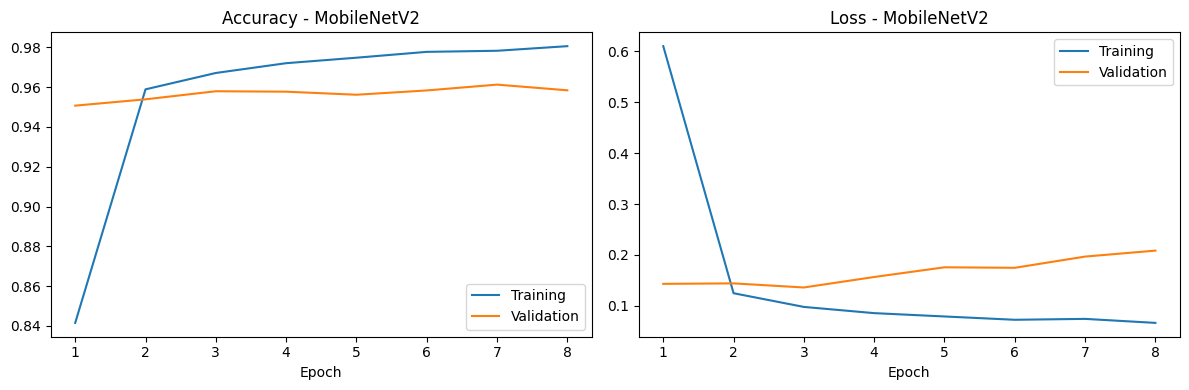

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range_mobilenet = range(1, len(history_mobilenet.history["accuracy"]) + 1)

# accuracy
ax1.plot(epochs_range_mobilenet, history_mobilenet.history["accuracy"], label="Training")
ax1.plot(epochs_range_mobilenet, history_mobilenet.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy - MobileNetV2")
ax1.set_xlabel("Epoch")
ax1.legend()

# loss
ax2.plot(epochs_range_mobilenet, history_mobilenet.history["loss"], label="Training")
ax2.plot(epochs_range_mobilenet, history_mobilenet.history["val_loss"], label="Validation")
ax2.set_title("Loss - MobileNetV2")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig("mobilenetv2_cnn.png")
plt.show()

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_generator_pretrained.reset()
y_pred_probs_mobilenet = model_mobilenet.predict(test_generator_pretrained)
y_pred_mobilenet = np.argmax(y_pred_probs_mobilenet, axis=1)
y_true_mobilenet = test_generator_pretrained.classes

class_names_mobilenet = list(test_generator_pretrained.class_indices.keys())
print(classification_report(y_true_mobilenet, y_pred_mobilenet, target_names=class_names_mobilenet, zero_division=0))
print(confusion_matrix(y_true_mobilenet, y_pred_mobilenet))

1429/1429 [==============================] - 285s 199ms/step
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       0.98      0.98      0.98       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       0.90      1.00      0.95       154
              Apple 13       0.95      0.96      0.96       235
              Apple 14       0.99      0.99      0.99       154
              Apple 17       0.98      0.95      0.96       201
              Apple 18       0.97      0.96      0.96       240
              Apple 19       1.00      0.98      0.99       241
              Apple 20       0.99      0.98      0.98       234
              Apple 21       1.00      0.90      0.95       162
              Apple 22       0.98      0.97      0.98       231
              Apple 23       1.00      1.00      1.00       156
               Apple 5       1.00      1.0

## Final CNN Experiment Comparison

Summary table of the main CNN experiments. The values are based on the test-set classification reports.

In [27]:
import pandas as pd

results = [
    {
        "Experiment": "Baseline CNN",
        "Main change": "32-64-128 filters, MaxPooling, no augmentation",
        "Test Accuracy": 0.94,
        "Macro Precision": 0.94,
        "Macro Recall": 0.94,
        "Macro F1-score": 0.94,
        "Comment": "Strong baseline; fulfills required thresholds."
    },
    {
        "Experiment": "CNN + Data Augmentation",
        "Main change": "Mild rotation, shift and zoom augmentation",
        "Test Accuracy": 0.95,
        "Macro Precision": 0.96,
        "Macro Recall": 0.95,
        "Macro F1-score": 0.95,
        "Comment": "Improves macro metrics compared with the baseline."
    },
    {
        "Experiment": "Small CNN",
        "Main change": "Reduced filters to 16-32-64",
        "Test Accuracy": 0.97,
        "Macro Precision": 0.97,
        "Macro Recall": 0.96,
        "Macro F1-score": 0.96,
        "Comment": "Very strong performance with fewer filters."
    },
    {
        "Experiment": "Large CNN",
        "Main change": "Increased filters to 64-128-256, Adam lr=0.0001",
        "Test Accuracy": 0.97,
        "Macro Precision": 0.97,
        "Macro Recall": 0.97,
        "Macro F1-score": 0.97,
        "Comment": "Best custom CNN; higher computational cost."
    },
    {
        "Experiment": "AveragePooling CNN",
        "Main change": "AveragePooling2D instead of MaxPooling2D",
        "Test Accuracy": 0.94,
        "Macro Precision": 0.95,
        "Macro Recall": 0.94,
        "Macro F1-score": 0.94,
        "Comment": "No improvement over MaxPooling baseline."
    },
    {
        "Experiment": "Stride/Padding CNN",
        "Main change": "First Conv2D uses strides=(2,2), padding='valid'",
        "Test Accuracy": 0.96,
        "Macro Precision": 0.96,
        "Macro Recall": 0.96,
        "Macro F1-score": 0.96,
        "Comment": "Faster than baseline and slightly better, but less stable."
    },
    {
        "Experiment": "MobileNetV2",
        "Main change": "Transfer learning with ImageNet pretrained MobileNetV2",
        "Test Accuracy": 0.97,
        "Macro Precision": 0.98,
        "Macro Recall": 0.98,
        "Macro F1-score": 0.98,
        "Comment": "Best overall macro metrics; fast convergence from pretrained features."
    },
]

results_df = pd.DataFrame(results)
results_df

,Experiment,Main change,Test Accuracy,Macro Precision,Macro Recall,Macro F1-score,Comment
0,Baseline CNN,"32-64-128 filters, MaxPooling, no augmentation",0.94,0.94,0.94,0.94,Strong baseline; fulfills required thresholds.
1,CNN + Data Augmentation,"Mild rotation, shift and zoom augmentation",0.95,0.96,0.95,0.95,Improves macro metrics compared with the basel...
2,Small CNN,Reduced filters to 16-32-64,0.97,0.97,0.96,0.96,Very strong performance with fewer filters.
3,Large CNN,"Increased filters to 64-128-256, Adam lr=0.0001",0.97,0.97,0.97,0.97,Best custom CNN; higher computational cost.
4,AveragePooling CNN,AveragePooling2D instead of MaxPooling2D,0.94,0.95,0.94,0.94,No improvement over MaxPooling baseline.
5,Stride/Padding CNN,"First Conv2D uses strides=(2,2), padding='valid'",0.96,0.96,0.96,0.96,"Faster than baseline and slightly better, but ..."
6,MobileNetV2,Transfer learning with ImageNet pretrained Mob...,0.97,0.98,0.98,0.98,Best overall macro metrics; fast convergence f...


In [28]:
best_models = results_df[results_df["Test Accuracy"] == results_df["Test Accuracy"].max()]

print("Best test accuracy:", results_df["Test Accuracy"].max())
print("Best model(s):")
display(best_models[["Experiment", "Test Accuracy", "Macro Precision", "Macro Recall", "Macro F1-score", "Comment"]])

Best test accuracy: 0.97
Best model(s):


,Experiment,Test Accuracy,Macro Precision,Macro Recall,Macro F1-score,Comment
2,Small CNN,0.97,0.97,0.96,0.96,Very strong performance with fewer filters.
3,Large CNN,0.97,0.97,0.97,0.97,Best custom CNN; higher computational cost.
6,MobileNetV2,0.97,0.98,0.98,0.98,Best overall macro metrics; fast convergence f...


In [29]:
results_df.to_csv("cnn_experiment_results.csv", index=False)
print("Saved comparison table to cnn_experiment_results.csv")

Saved comparison table to cnn_experiment_results.csv


## Feature-Map / Convolution Visualization

Visualization of the activation maps produced by the first convolutional layer of the best custom CNN model. This helps illustrate what kind of low-level visual patterns the CNN extracts from an input fruit image.

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Conv2D

# Use the best custom CNN. If the model is not in memory, load it from the saved checkpoint.
if "model_large" in globals():
    analysis_model = model_large
else:
    analysis_model = load_model("best_model_large_lr0001.h5")

analysis_generator = test_generator
analysis_class_names = list(analysis_generator.class_indices.keys())

# Pick one image from the test set.
example_index = 0
example_relative_path = analysis_generator.filenames[example_index]
example_path = os.path.join(test_dir, example_relative_path)
example_true_class = analysis_class_names[analysis_generator.classes[example_index]]

img = load_img(example_path, target_size=IMG_SIZE)
img_array = img_to_array(img) / 255.0
img_batch = np.expand_dims(img_array, axis=0)

# Find the first convolutional layer automatically.
first_conv_layer = next(layer for layer in analysis_model.layers if isinstance(layer, Conv2D))
feature_model = Model(inputs=analysis_model.input, outputs=first_conv_layer.output)
feature_maps = feature_model.predict(img_batch)

print("Image:", example_relative_path)
print("True class:", example_true_class)
print("Visualized layer:", first_conv_layer.name)
print("Feature map shape:", feature_maps.shape)

2026-06-14 04:40:24.913430: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-06-14 04:40:24.913794: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2026-06-14 04:40:24.913867: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (814d7a98307b): /proc/driver/nvidia/version does not exist
2026-06-14 04:40:24.914960: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


1/1 [==============================] - 0s 117ms/step
Image: Almonds 1/r0_103_100.jpg
True class: Almonds 1
Visualized layer: conv2d_12
Feature map shape: (1, 100, 100, 64)


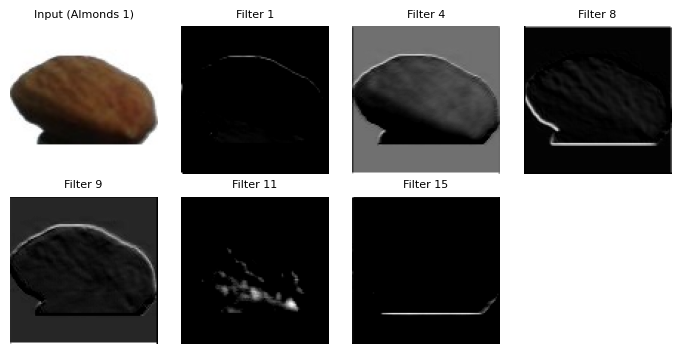

In [5]:
selected = [0, 3, 7, 8, 10, 14]  # -> Filter 1, 4, 8, 9, 11, 15

fig, axes = plt.subplots(2, 4, figsize=(7, 3.6))
axes = axes.flatten()

axes[0].imshow(img_array)
axes[0].set_title("Input (Almonds 1)", fontsize=8)
axes[0].axis("off")

for ax, idx in zip(axes[1:7], selected):
    ax.imshow(feature_maps[0, :, :, idx], cmap="gray")
    ax.set_title(f"Filter {idx + 1}", fontsize=8)
    ax.axis("off")

axes[7].axis("off")

plt.tight_layout()
plt.savefig("feature_maps_first_conv.png", dpi=200, bbox_inches="tight")
plt.show()

## Best-Case and Worst-Case Predictions

The following cells identify confident correct predictions and confident incorrect predictions on the test set. These examples can be used in the paper as best-case and worst-case scenarios.

In [6]:
import pandas as pd

analysis_generator.reset()
y_pred_probs_analysis = analysis_model.predict(analysis_generator)
y_pred_analysis = np.argmax(y_pred_probs_analysis, axis=1)
y_true_analysis = analysis_generator.classes
confidence_analysis = np.max(y_pred_probs_analysis, axis=1)

prediction_results = pd.DataFrame({
    "filename": analysis_generator.filenames,
    "true_index": y_true_analysis,
    "pred_index": y_pred_analysis,
    "confidence": confidence_analysis
})

prediction_results["true_class"] = prediction_results["true_index"].apply(lambda i: analysis_class_names[i])
prediction_results["predicted_class"] = prediction_results["pred_index"].apply(lambda i: analysis_class_names[i])
prediction_results["correct"] = prediction_results["true_index"] == prediction_results["pred_index"]

best_cases = (prediction_results[prediction_results["correct"]].sort_values("confidence", ascending=False).drop_duplicates(subset="true_class").head(3))
worst_cases = prediction_results[~prediction_results["correct"]].sort_values("confidence", ascending=False).head(3)

print("Best-case examples:")
display(best_cases[["filename", "true_class", "predicted_class", "confidence"]])

print("Worst-case examples:")
display(worst_cases[["filename", "true_class", "predicted_class", "confidence"]])

1429/1429 [==============================] - 464s 325ms/step
Best-case examples:


,filename,true_class,predicted_class,confidence
45723,orange 4/r3_99_100.jpg,orange 4,orange 4,1.0
27756,Peach 3/r3_3_100.jpg,Peach 3,Peach 3,1.0
27854,Peach 4/r1_107_100.jpg,Peach 4,Peach 4,1.0


Worst-case examples:


,filename,true_class,predicted_class,confidence
8148,Blackberry 4/r1_75_100.jpg,Blackberry 4,Blackberry 1,1.0
7954,Blackberry 3/r1_167_100.jpg,Blackberry 3,Blackberry 4,1.0
7942,Blackberry 3/r1_123_100.jpg,Blackberry 3,Blackberry 4,1.0


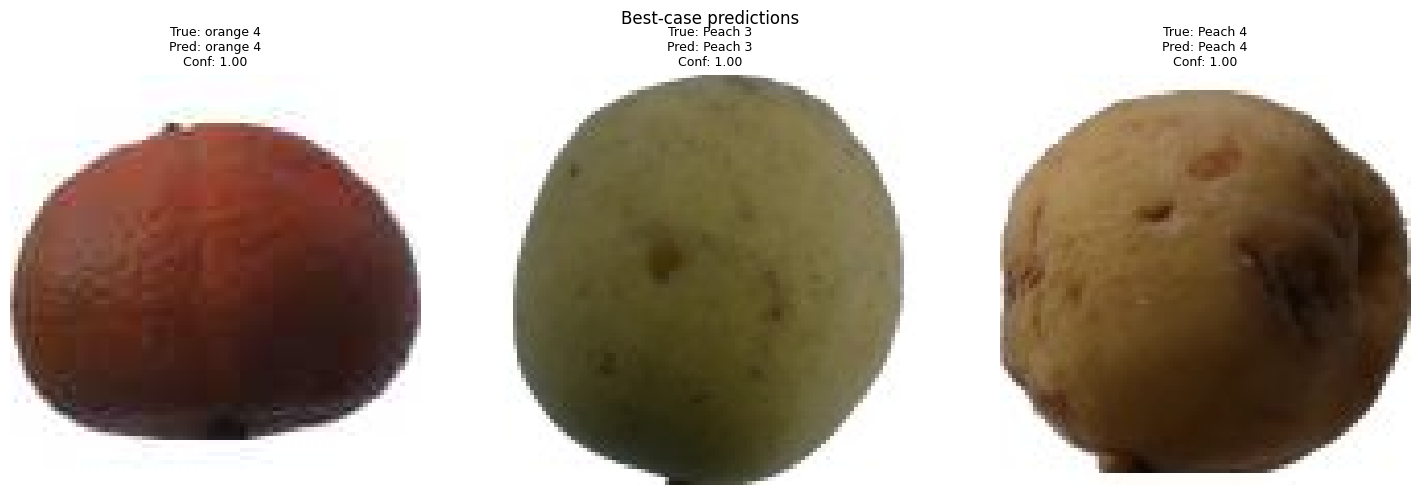

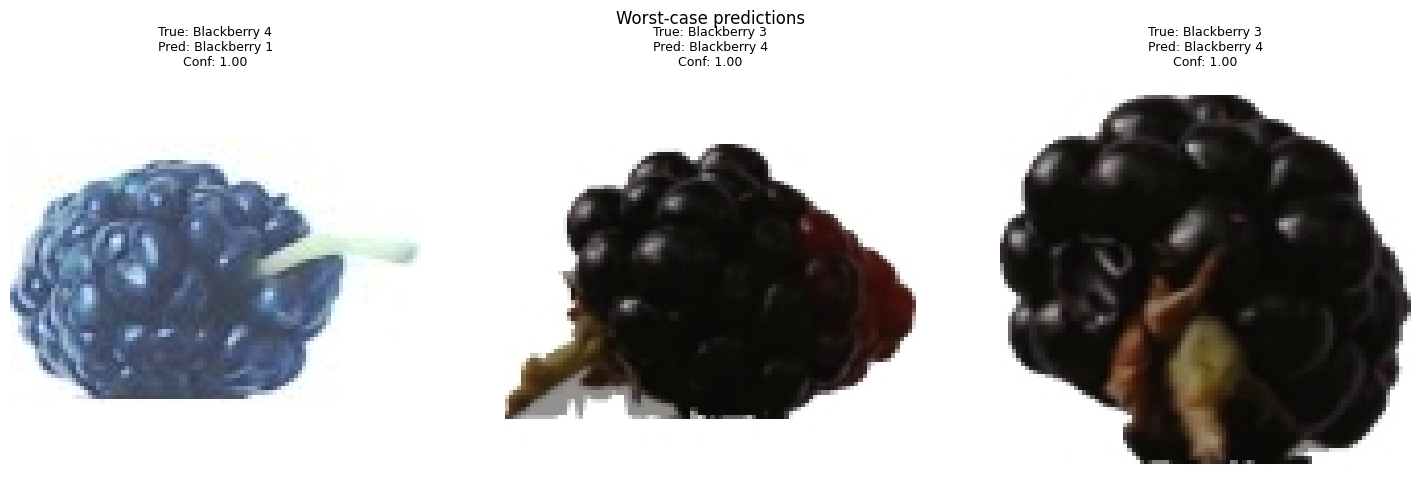

In [7]:
def plot_prediction_examples(df, title, output_file):
    fig, axes = plt.subplots(1, len(df), figsize=(5 * len(df), 5))
    if len(df) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, df.iterrows()):
        image_path = os.path.join(test_dir, row["filename"])
        image = load_img(image_path, target_size=IMG_SIZE)
        ax.imshow(image)
        title_text = f"True: {row['true_class']}\nPred: {row['predicted_class']}\nConf: {row['confidence']:.2f}"
        ax.set_title(title_text, fontsize=9)
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(output_file)
    plt.show()

plot_prediction_examples(best_cases, "Best-case predictions", "best_case_predictions.png")
plot_prediction_examples(worst_cases, "Worst-case predictions", "worst_case_predictions.png")

## Confusion Matrix as Image

The full confusion matrix is saved as an image. Because the dataset contains 260 classes, an additional focused confusion matrix is generated for the classes with the most errors, which is easier to read in the paper.

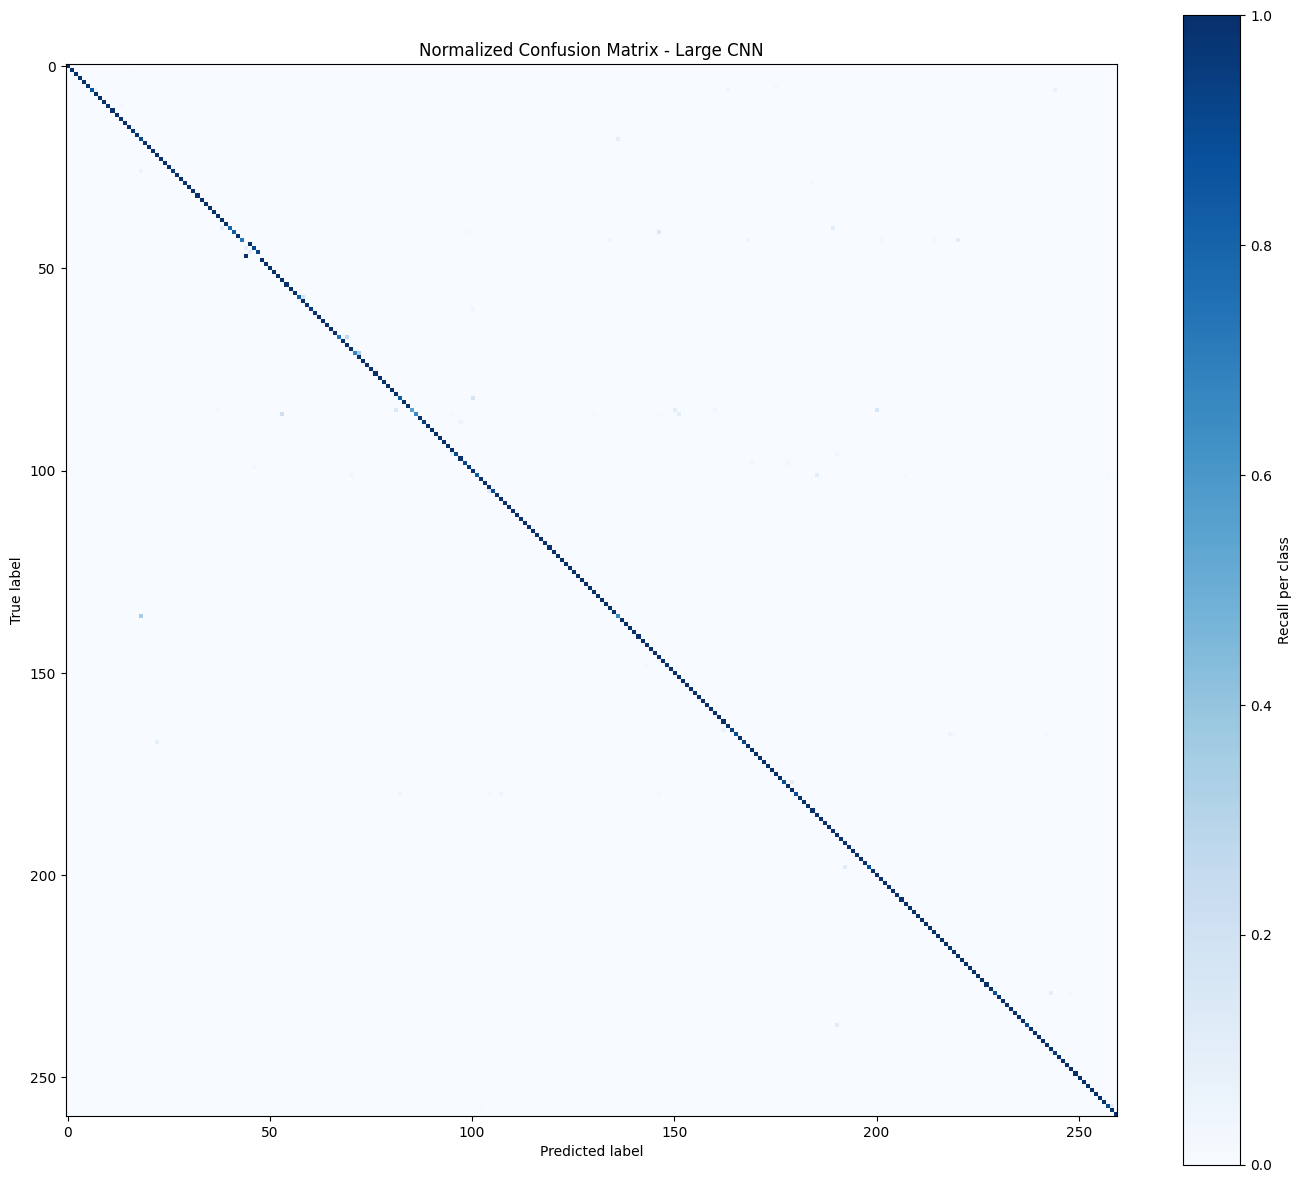

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_analysis, y_pred_analysis)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(14, 12))
plt.imshow(cm_normalized, interpolation="nearest", cmap="Blues")
plt.title("Normalized Confusion Matrix - Large CNN")
plt.colorbar(label="Recall per class")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("confusion_matrix_large_cnn_full.png", dpi=200)
plt.show()

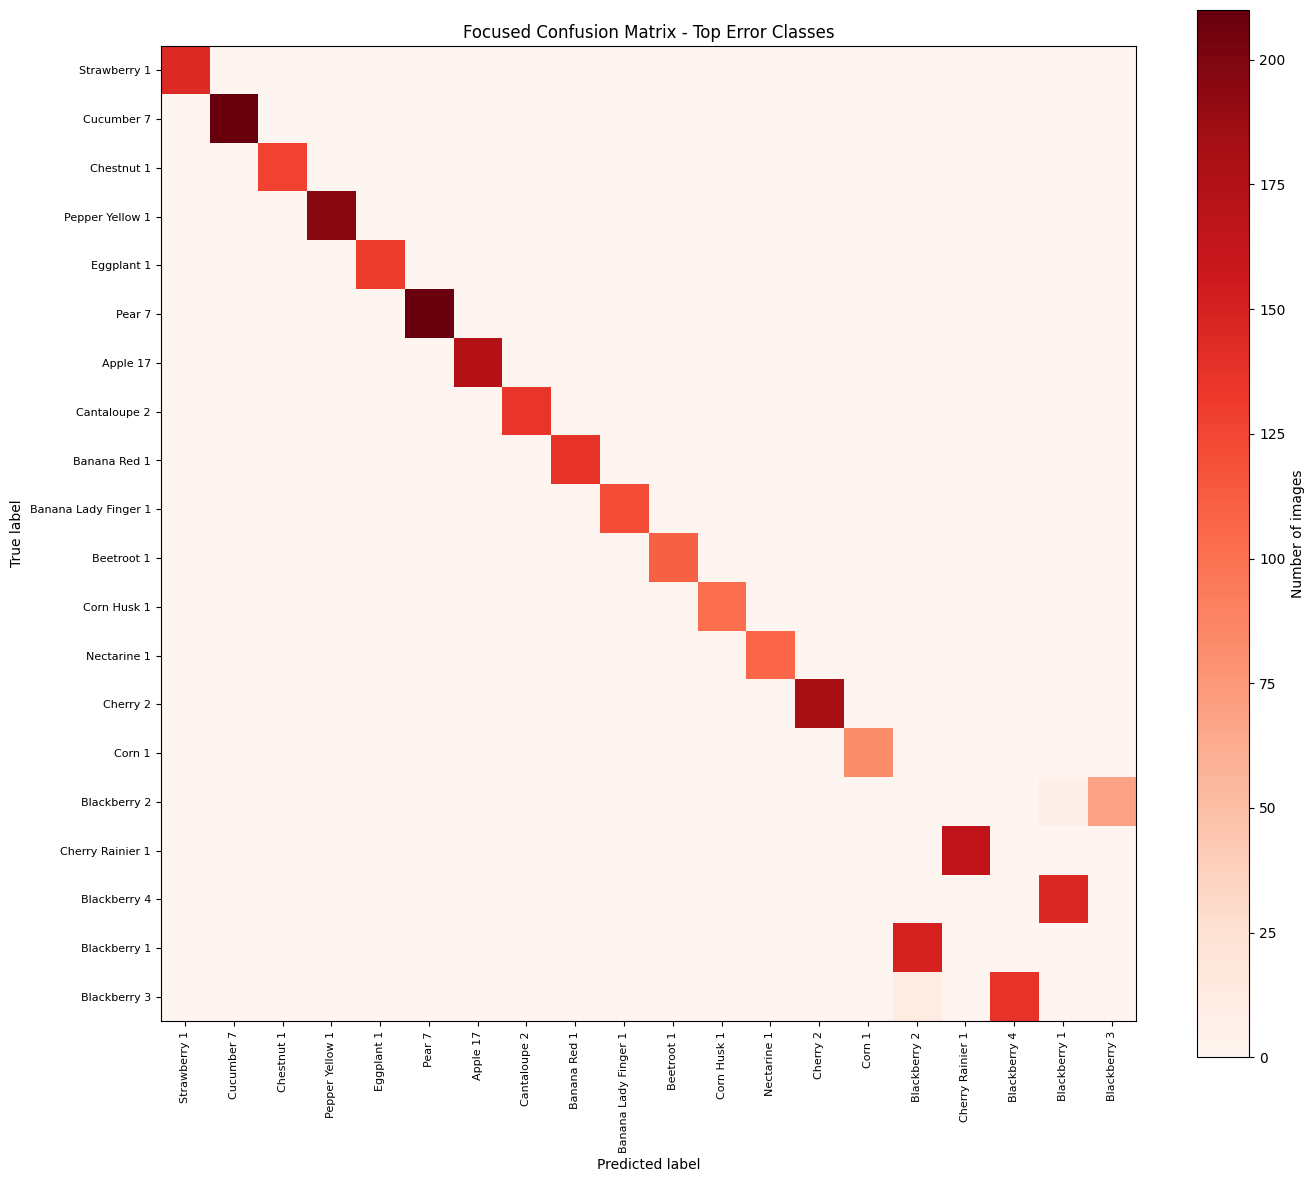

,class,errors
19,Blackberry 3,150
18,Blackberry 1,150
17,Blackberry 4,145
16,Cherry Rainier 1,80
15,Blackberry 2,75
14,Corn 1,68
13,Cherry 2,64
12,Nectarine 1,57
11,Corn Husk 1,53
10,Beetroot 1,40


In [9]:
# Focused confusion matrix for the classes with the largest number of errors.
errors_per_class = cm.sum(axis=1) - np.diag(cm)
top_error_indices = np.argsort(errors_per_class)[-20:]

cm_focus = cm[np.ix_(top_error_indices, top_error_indices)]
focus_labels = [analysis_class_names[i] for i in top_error_indices]

plt.figure(figsize=(14, 12))
plt.imshow(cm_focus, interpolation="nearest", cmap="Reds")
plt.title("Focused Confusion Matrix - Top Error Classes")
plt.colorbar(label="Number of images")
plt.xticks(range(len(focus_labels)), focus_labels, rotation=90, fontsize=8)
plt.yticks(range(len(focus_labels)), focus_labels, fontsize=8)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("confusion_matrix_large_cnn_top_errors.png", dpi=200)
plt.show()

error_summary = pd.DataFrame({
    "class": focus_labels,
    "errors": errors_per_class[top_error_indices]
}).sort_values("errors", ascending=False)

display(error_summary)